# Tutorial 6: Cluster Analysis

This tutorial demonstrates how to analyze stellar clusters using brutus, including isochrone fitting, binary fraction inference via MCMC, and parameter estimation.

## Topics Covered

1. **Loading cluster data** (M67 example)
2. **Isochrone fitting** with `isochrone_population_loglike`
3. **Cluster parameters** (age, metallicity, distance, extinction)
4. **MCMC sampling** for cluster parameters including binary fraction
5. **Binary fraction** inference from photometric data
6. **Posterior visualization** (corner plots, trace plots)

## Prerequisites

This tutorial requires the following brutus data files:
- `MIST_1.2_iso_vvcrit0.0.h5` - MIST isochrones
- `nn_c3k.h5` - Neural network for bolometric corrections
- `NGC_2682.fits` - M67 cluster data

If you don't have these files, run the optional download cell below.

In [1]:
# Imports and setup
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from tutorial_utils import (
    setup_tutorial,
    find_brutus_data_file,
    save_figure as _save_fig,
    print_section,
    load_m67_data,
)

info = setup_tutorial(6, title="Tutorial 06: Cluster Analysis")
plots_dir = info['plot_dir']


def save_figure(fig, name):
    """Save figure to this tutorial's plot directory."""
    _save_fig(fig, 6, name)


Tutorial 06: Cluster Analysis

Checking data requirements for Tutorial 6
  Found: nn_c3k.h5
  Found: MIST_1.2_iso_vvcrit0.0.h5
  Found: offsets_mist_v9.txt
  Found: NGC_2682.fits

  All required files available


In [ ]:
from brutus.utils import inv_magnitude
from brutus.data import filters

# Load M67 data
print("Loading M67 cluster data...")
data_dict = load_m67_data()
fdata = data_dict['data']
Nobj = len(fdata)
print(f"  Loaded {Nobj} sources")

# ---- Define the combined filter set: Gaia + PS1(grizy) + 2MASS ----
# This gives 11 bands spanning optical through near-IR.
combined_filters = filters.gaia + filters.ps[:5] + filters.tmass
n_filters = len(combined_filters)
print(f"  Using {n_filters} filters: {combined_filters}")

# ---- Column names in the FITS catalogue ----
mag_columns = [
    # Gaia DR2 (revised passband)
    'Gaia_G_DR2Rev', 'Gaia_BP_DR2Rev', 'Gaia_RP_DR2Rev',
    # Pan-STARRS grizy
    'PS_g', 'PS_r', 'PS_i', 'PS_z', 'PS_y',
    # 2MASS JHKs
    '2MASS_J', '2MASS_H', '2MASS_Ks',
]
err_columns = [c + '_Err' for c in mag_columns]

# ---- Convert calibrated magnitudes to maggies ----
# brutus works in "maggie" units: flux = 10^(-0.4 * mag), with no
# zero-point offset.  inv_magnitude handles NaN gracefully.
all_mag = np.column_stack([fdata[c] for c in mag_columns])
all_magerr = np.column_stack([fdata[c] for c in err_columns])

phot, err = inv_magnitude(all_mag, all_magerr)

# Add a 2% systematic error floor (accounts for model systematics)
err = np.sqrt(err**2 + (0.02 * phot)**2)
mask = np.isfinite(phot) & (err > 0) & (phot > 0)

# Replace NaN/invalid values with safe placeholders for masked bands.
# The mask tells the likelihood to skip these, but phot_loglike needs
# finite values everywhere to avoid NaN propagation (NaN * 0 = NaN).
phot = np.where(mask, phot, 1.0)
err = np.where(mask, err, 1.0)

# Band availability summary
band_names = ['G', 'BP', 'RP', 'g_PS', 'r_PS', 'i_PS', 'z_PS', 'y_PS',
              'J', 'H', 'Ks']
print("\nBand availability (all sources):")
for i, name in enumerate(band_names):
    n_valid = np.sum(mask[:, i])
    print(f"  {name:>5s}: {n_valid:4d}/{Nobj} ({100*n_valid/Nobj:.0f}%)")

# ---- Parallax (with Gaia DR2 zero-point correction) ----
parallax = fdata['Parallax'] + 0.054          # Lindegren et al. 2018
parallax_err = np.sqrt(fdata['Parallax_Err']**2 + 0.043**2)

# ---- Membership probability ----
try:
    pmem = fdata['HDBscan_MemProb']
    print("\n  Found membership probabilities")
except Exception:
    pmem = np.ones(Nobj)
    print("\n  No membership info, assuming all are members")

# ---- Quality cuts ----
# Require: at least 4 valid bands (consistent with Tutorial 5),
# high membership probability, and a valid parallax measurement.
gaia_g = all_mag[:, 0]
n_valid_bands = np.sum(mask, axis=1)
quality = (
    (pmem > 0.5)
    & (n_valid_bands >= 4)
    & np.isfinite(parallax)
)

# Store Gaia mags for CMD plotting later
gaia_mag = all_mag[:, :3]

print(f"\nHigh-confidence members: {quality.sum()} / {Nobj}")
print(f"  Median valid bands per star: {np.median(n_valid_bands[quality]):.0f}")
print(f"  Mean parallax: {np.nanmean(parallax[quality]):.3f} "
      f"+/- {np.nanstd(parallax[quality]):.3f} mas")
print(f"  Implied distance: {1000 / np.nanmean(parallax[quality]):.0f} pc")

In [3]:
# Extract auxiliary columns for plotting
try:
    ra = fdata['gaia_dr2_source.ra']
    dec = fdata['gaia_dr2_source.dec']
except Exception:
    ra = np.full(Nobj, np.nan)
    dec = np.full(Nobj, np.nan)

# Package selected data for analysis
cluster_data = {
    'phot': phot[quality],
    'err': err[quality],
    'mask': mask[quality],
    'parallax': parallax[quality],
    'parallax_err': parallax_err[quality],
    'pmem': pmem[quality],
}

n_stars = len(cluster_data['phot'])
cluster_prob = np.mean(cluster_data['pmem'])

print(f"Data ready for analysis: {n_stars} stars, cluster_prob = {cluster_prob:.3f}")

Data ready for analysis: 754 stars, cluster_prob = 0.741


  Saved: /mnt/c/Users/joshs/Dropbox/GitHub/brutus/tutorials/plots/tutorial_06/cluster_data.png


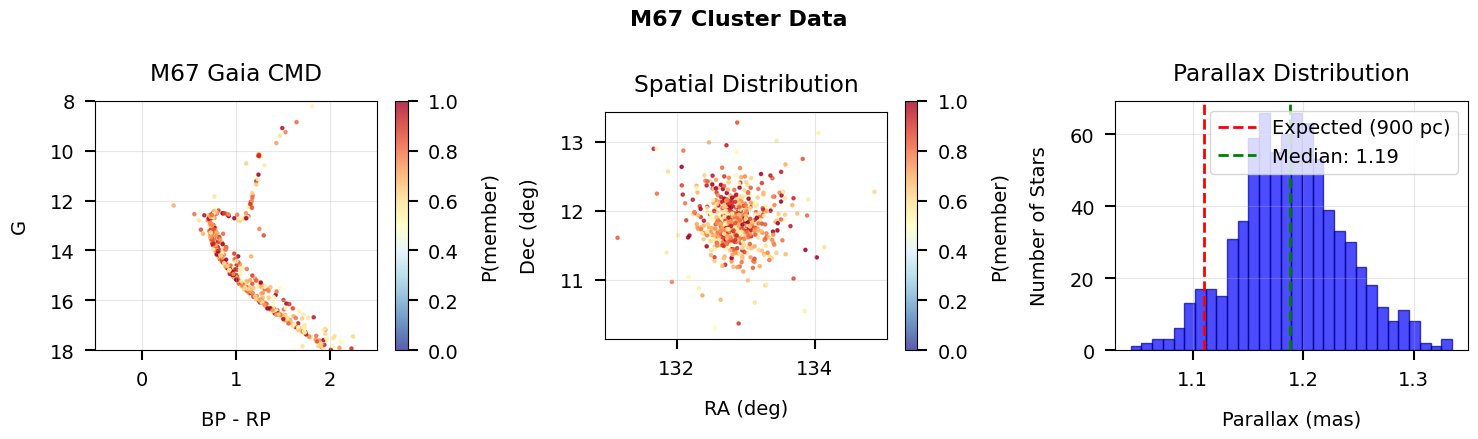

In [4]:
# Visualize cluster data
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Gaia magnitudes for CMD plotting (indices 0,1,2 = G, BP, RP)
bp_rp = gaia_mag[:, 1] - gaia_mag[:, 2]
g = gaia_mag[:, 0]

# Panel 1: Gaia CMD
ax = axes[0]
scatter = ax.scatter(bp_rp[quality], g[quality],
                    c=pmem[quality], s=5, cmap='RdYlBu_r',
                    vmin=0, vmax=1, alpha=0.8)
ax.set_xlabel('BP - RP')
ax.set_ylabel('G')
ax.set_title('M67 Gaia CMD')
ax.invert_yaxis()
ax.set_xlim(-0.5, 2.5)
ax.set_ylim(18, 8)
plt.colorbar(scatter, ax=ax, label='P(member)')
ax.grid(True, alpha=0.3)

# Panel 2: Spatial distribution
ax = axes[1]
try:
    ra = fdata['gaia_dr2_source.ra']
    dec = fdata['gaia_dr2_source.dec']
except Exception:
    ra = np.full(Nobj, np.nan)
    dec = np.full(Nobj, np.nan)
scatter = ax.scatter(ra[quality], dec[quality], c=pmem[quality],
                    s=5, cmap='RdYlBu_r', vmin=0, vmax=1, alpha=0.8)
ax.set_xlabel('RA (deg)')
ax.set_ylabel('Dec (deg)')
ax.set_title('Spatial Distribution')
ax.set_aspect('equal')
plt.colorbar(scatter, ax=ax, label='P(member)')
ax.grid(True, alpha=0.3)

# Panel 3: Parallax distribution
ax = axes[2]
valid_plx = quality & np.isfinite(parallax)
ax.hist(parallax[valid_plx], bins=30, alpha=0.7, color='blue', edgecolor='darkblue')
ax.axvline(1.11, color='red', ls='--', lw=2, label='Expected (900 pc)')
ax.axvline(np.median(parallax[valid_plx]), color='green', ls='--', lw=2,
           label=f'Median: {np.median(parallax[valid_plx]):.2f}')
ax.set_xlabel('Parallax (mas)')
ax.set_ylabel('Number of Stars')
ax.set_title('Parallax Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('M67 Cluster Data', fontsize=16, fontweight='bold')
plt.tight_layout()
save_figure(fig, 'cluster_data')
plt.show()

In [5]:
# Load isochrone models and set up population fitting
from brutus.core import Isochrone, StellarPop
from brutus.analysis import isochrone_population_loglike

print_section("Setting up isochrone models")

# Load data files
mistfile = find_brutus_data_file('MIST_1.2_iso_vvcrit0.0.h5')
nnfile = find_brutus_data_file('nn_c3k.h5')

# Initialize models with combined filter set (Gaia + PS1 + 2MASS = 11 bands)
iso = Isochrone(mistfile=mistfile)
stellarpop = StellarPop(iso, nnfile=nnfile, filters=combined_filters)

print(f"  Isochrone file: {Path(mistfile).name}")
print(f"  NN file: {Path(nnfile).name}")
print(f"  Filters ({n_filters}): {combined_filters}")
print(f"  Model ready for population analysis")


Setting up isochrone models


Constructing MIST isochrones...


  Isochrone file: MIST_1.2_iso_vvcrit0.0.h5
  NN file: nn_c3k.h5
  Filters (11): ['Gaia_G_MAW', 'Gaia_BP_MAWf', 'Gaia_RP_MAW', 'PS_g', 'PS_r', 'PS_i', 'PS_z', 'PS_y', '2MASS_J', '2MASS_H', '2MASS_Ks']
  Model ready for population analysis


done!
Initializing FastNN predictor...done!


In [6]:
# Initial guess for M67 parameters
# isochrone_population_loglike expects theta = [feh, loga, av, rv, dist, field_frac]
theta_init = [
    0.0,    # [Fe/H] - solar metallicity
    9.55,   # log(age) ~ 3.5 Gyr
    0.05,   # A(V) - small extinction
    3.32,   # R(V) - standard
    900.0,  # distance (pc)
    0.05,   # field_frac - field contamination fraction
]

print("Computing initial likelihood...")
lnl_init = isochrone_population_loglike(
    theta_init,
    stellarpop,
    cluster_data['phot'],
    cluster_data['err'],
    parallax=cluster_data['parallax'],
    parallax_err=cluster_data['parallax_err'],
    cluster_prob=cluster_prob,
    mask=cluster_data['mask'],
)

print(f"\nInitial parameters:")
print(f"  [Fe/H] = {theta_init[0]:.2f}")
print(f"  Age = {10**(theta_init[1]-9):.2f} Gyr")
print(f"  A(V) = {theta_init[2]:.3f}")
print(f"  R(V) = {theta_init[3]:.2f}")
print(f"  Distance = {theta_init[4]:.0f} pc")
print(f"  Field fraction = {theta_init[5]:.2f}")
print(f"\nInitial log-likelihood: {lnl_init:.1f}")

Computing initial likelihood...



Initial parameters:
  [Fe/H] = 0.00
  Age = 3.55 Gyr
  A(V) = 0.050
  R(V) = 3.32
  Distance = 900 pc
  Field fraction = 0.05

Initial log-likelihood: -9286.8


In [7]:
# Optimize cluster parameters using Powell's method
from scipy.optimize import minimize

print_section("Optimizing cluster parameters")
print("Using Powell's method (derivative-free, respects bounds)...\n")

def neg_loglike(theta):
    """Negative log-likelihood for optimization."""
    lnl = isochrone_population_loglike(
        theta,
        stellarpop,
        cluster_data['phot'],
        cluster_data['err'],
        parallax=cluster_data['parallax'],
        parallax_err=cluster_data['parallax_err'],
        cluster_prob=cluster_prob,
        mask=cluster_data['mask'],
    )
    if not np.isfinite(lnl):
        return 1e30
    return -lnl

# Set reasonable bounds
bounds = [
    (-0.5, 0.5),    # [Fe/H]
    (9.0, 10.0),    # log(age)
    (0.0, 0.5),     # A(V)
    (2.0, 5.0),     # R(V)
    (700, 1100),    # distance (pc)
    (0.0, 0.5),     # field_frac
]

# Optimize
result = minimize(
    neg_loglike,
    theta_init,
    method='Powell',
    bounds=bounds,
    options={'maxiter': 100, 'ftol': 1.0}
)

theta_best = result.x
lnl_best = -result.fun

print(f"\nOptimization complete ({result.nfev} evaluations)")
print(f"  Final log-likelihood: {lnl_best:.1f}")
print(f"  Improvement over initial: {lnl_best - lnl_init:.1f}")
print("\nBest-fit parameters:")
print(f"  [Fe/H] = {theta_best[0]:+.3f}")
print(f"  Age = {10**(theta_best[1]-9):.2f} Gyr  (log(age) = {theta_best[1]:.3f})")
print(f"  A(V) = {theta_best[2]:.3f}  ->  E(B-V) ~ {theta_best[2]/theta_best[3]:.3f}")
print(f"  R(V) = {theta_best[3]:.2f}")
print(f"  Distance = {theta_best[4]:.0f} pc")
print(f"  Field fraction = {theta_best[5]:.3f}")


Optimizing cluster parameters
Using Powell's method (derivative-free, respects bounds)...




Optimization complete (79 evaluations)
  Final log-likelihood: -7354.5
  Improvement over initial: 1932.3

Best-fit parameters:
  [Fe/H] = +0.221
  Age = 3.83 Gyr  (log(age) = 9.583)
  A(V) = 0.054  ->  E(B-V) ~ 0.017
  R(V) = 3.17
  Distance = 889 pc
  Field fraction = 0.164


  Saved: /mnt/c/Users/joshs/Dropbox/GitHub/brutus/tutorials/plots/tutorial_06/isochrone_fitting.png


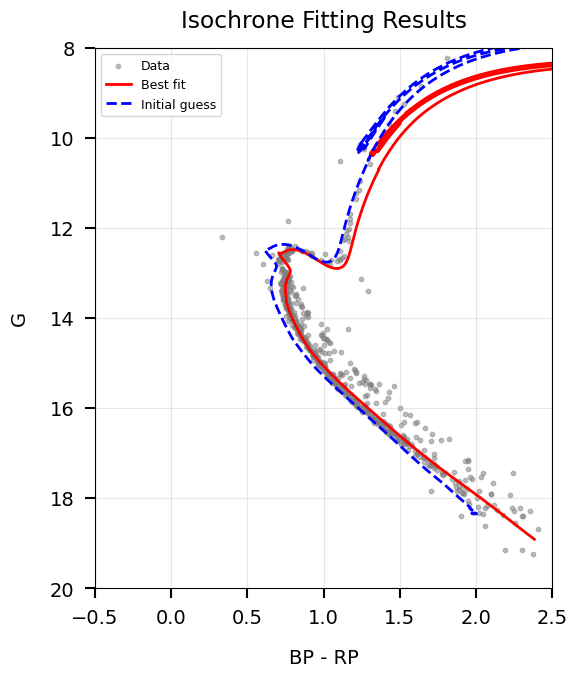

In [8]:
# Generate best-fit isochrone for visualization
eep_grid = np.linspace(202, 808, 2000)

# Gaia band indices in the combined filter array
iG, iBP, iRP = 0, 1, 2

# Get photometry from StellarPop for best-fit parameters
mags_best, _, _ = stellarpop.get_seds(
    feh=theta_best[0], afe=0.0, loga=theta_best[1], eep=eep_grid,
    av=theta_best[2], rv=theta_best[3], dist=theta_best[4],
    binary_fraction=0.0,
)

# Also generate the initial-guess isochrone for comparison
mags_init, _, _ = stellarpop.get_seds(
    feh=theta_init[0], afe=0.0, loga=theta_init[1], eep=eep_grid,
    av=theta_init[2], rv=theta_init[3], dist=theta_init[4],
    binary_fraction=0.0,
)

# Observed CMD colors (Gaia bands for plotting)
gaia_mag_q = gaia_mag[quality]
bp_rp_obs = gaia_mag_q[:, 1] - gaia_mag_q[:, 2]
g_obs = gaia_mag_q[:, 0]

# CMD with best-fit and initial isochrones
fig, ax = plt.subplots(figsize=(6, 7))
ax.scatter(bp_rp_obs, g_obs, s=10, alpha=0.5, color='gray', label='Data')

# Best-fit isochrone (use Gaia bands from 11-band SED)
valid_best = np.all(np.isfinite(mags_best[:, [iG, iBP, iRP]]), axis=1)
ax.plot(mags_best[valid_best, iBP] - mags_best[valid_best, iRP],
        mags_best[valid_best, iG], 'r-', lw=2, label='Best fit')

# Initial guess isochrone
valid_init = np.all(np.isfinite(mags_init[:, [iG, iBP, iRP]]), axis=1)
ax.plot(mags_init[valid_init, iBP] - mags_init[valid_init, iRP],
        mags_init[valid_init, iG], 'b--', lw=2, label='Initial guess')

ax.set_xlabel('BP - RP')
ax.set_ylabel('G')
ax.set_title('Isochrone Fitting Results')
ax.invert_yaxis()
ax.set_xlim(-0.5, 2.5)
ax.set_ylim(20, 8)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_figure(fig, 'isochrone_fitting')
plt.show()

## Section 3: MCMC Sampling with Binary Fraction

The optimizer above found a good point estimate, but we want **posterior distributions** for all cluster parameters -- including the **binary fraction**.

Unresolved binaries affect cluster CMDs by:
- **Broadening** the main sequence (binaries appear brighter than single stars)
- Creating **sequences above** the single-star main sequence
- Affecting the **turnoff luminosity** and inferred age

Rather than assuming a fixed binary fraction, we can **fit it as a free parameter** alongside age, metallicity, distance, and extinction. The key idea is that `isochrone_population_loglike` internally marginalizes over a grid of secondary mass fractions (SMF). By adjusting the **relative weighting** of single-star (SMF=0) vs. binary (SMF>0) grid points, we control the effective binary fraction.

We will use `emcee` to sample the 7-dimensional parameter space:
**[Fe/H], log(age), A(V), R(V), distance, field_fraction, binary_fraction**

In [ ]:
# MCMC sampling of cluster parameters including binary fraction
import emcee
from brutus.analysis.populations import (
    generate_isochrone_population_grid,
    compute_isochrone_cluster_loglike,
    compute_isochrone_outlier_loglike,
    apply_isochrone_mixture_model,
    marginalize_isochrone_grid,
)

print_section("MCMC sampling with binary fraction")

# ---- Parameter labels and bounds ----
param_names = ['[Fe/H]', 'log(age)', 'A(V)', 'R(V)',
               'distance', 'field_frac', 'binary_frac']
bounds = np.array([
    [-0.5,  0.5],    # [Fe/H]
    [ 9.0, 10.0],    # log(age)
    [ 0.0,  0.5],    # A(V)
    [ 2.0,  5.0],    # R(V)
    [700., 1100.],   # distance (pc)
    [ 0.001, 0.5],   # field_frac (avoid log(0))
    [ 0.0,  1.0],    # binary_frac
])

# ---- Log-likelihood that includes binary_fraction ----
# The standard isochrone_population_loglike marginalizes over an SMF grid
# where SMF=0 represents single stars and SMF>0 represents binaries with
# various mass ratios.  By default, the SMF grid is uniformly weighted.
#
# To incorporate binary_fraction, we:
#   1. Generate the isochrone grid (with SMF values from 0 to 1)
#   2. Re-weight the SMF jacobians:
#      - SMF=0 points get weight proportional to (1 - f_binary)
#      - SMF>0 points get weight proportional to f_binary
#   3. Compute the rest of the likelihood as usual

# Pre-compute the SMF and EEP grids (shared across all evaluations)
smf_grid = np.linspace(0.0, 1.0, 21)
eep_grid = np.linspace(202.0, 808.0, 500)

def log_likelihood_with_binary(theta7):
    """Log-likelihood for 7 parameters including binary fraction."""
    feh, loga, av, rv, dist, field_frac, binary_frac = theta7

    # Check bounds
    for val, (lo, hi) in zip(theta7, bounds):
        if val < lo or val > hi:
            return -np.inf

    try:
        # Step 1: Generate isochrone grid
        grid = generate_isochrone_population_grid(
            stellarpop, feh, loga, av, rv, dist,
            smf_grid=smf_grid, eep_grid=eep_grid,
        )

        # Step 2: Re-weight SMF jacobians by binary fraction
        # Points with SMF=0 are single stars: weight = (1 - binary_frac)
        # Points with SMF>0 are binaries: weight = binary_frac
        smf_vals = grid['smf_values']
        smf_jac = grid['smf_jacobians'].copy()

        # Post-MS rows (EEP > eep_binary_max) are SMF-independent: the grid
        # stores them once carrying the FULL SMF measure (sum of all grid
        # spacings), and no companion is modeled for them, so their weight
        # must not depend on the binary fraction. Identify them by that
        # full measure and leave their jacobians unchanged.
        total_smf_measure = np.sum(np.gradient(smf_grid))
        is_postms = np.isclose(smf_jac, total_smf_measure)

        is_single = (smf_vals == 0.0) & ~is_postms
        is_binary = (smf_vals > 0.0) & ~is_postms

        # Original total SMF weight for normalization
        n_binary_smf = np.sum(smf_grid > 0)
        smf_spacing = smf_grid[1] - smf_grid[0] if len(smf_grid) > 1 else 1.0

        # Re-weight: single stars get (1 - f_b), binaries get f_b
        # The binary SMF points share the f_b weight, keeping their
        # relative spacing (so uniform mass-ratio prior is preserved).
        if np.any(is_single):
            smf_jac[is_single] = (1.0 - binary_frac)
        if np.any(is_binary) and n_binary_smf > 0:
            smf_jac[is_binary] = binary_frac * smf_jac[is_binary] / (
                n_binary_smf * smf_spacing
            )

        grid['smf_jacobians'] = smf_jac

        # Step 3: Compute cluster likelihood
        lnl_cluster = compute_isochrone_cluster_loglike(
            cluster_data['phot'], cluster_data['err'], grid,
            parallax=cluster_data['parallax'],
            parallax_err=cluster_data['parallax_err'],
            distance=dist, mask=cluster_data['mask'],
        )

        # Step 4: Compute outlier likelihood
        lnl_outlier = compute_isochrone_outlier_loglike(
            cluster_data['phot'], cluster_data['err'], grid,
            parallax=cluster_data['parallax'],
            parallax_err=cluster_data['parallax_err'],
            mask=cluster_data['mask'],
        )

        # Step 5: Apply mixture model (cluster vs. field)
        lnl_mixture = apply_isochrone_mixture_model(
            lnl_cluster, lnl_outlier, cluster_prob, field_frac,
        )

        # Step 6: Marginalize over (mass, SMF) and sum over objects
        lnl_marg = marginalize_isochrone_grid(
            lnl_mixture, grid['mass_jacobians'], grid['smf_jacobians'],
        )
        lnl_total = np.sum(lnl_marg)

        if not np.isfinite(lnl_total):
            return -np.inf
        return lnl_total

    except Exception:
        return -np.inf

def log_prior(theta7):
    """Flat priors within bounds, plus a Gaussian prior on R(V)."""
    for val, (lo, hi) in zip(theta7, bounds):
        if val < lo or val > hi:
            return -np.inf
    # Gaussian prior on R(V): mean=3.32, sigma=0.18
    rv = theta7[3]
    lnp = -0.5 * ((rv - 3.32) / 0.18)**2
    return lnp

def log_posterior(theta7):
    """Log-posterior = log-prior + log-likelihood."""
    lp = log_prior(theta7)
    if not np.isfinite(lp):
        return -np.inf
    ll = log_likelihood_with_binary(theta7)
    if not np.isfinite(ll):
        return -np.inf
    return lp + ll

# ---- Initialize walkers around the optimized solution ----
ndim = 7
nwalkers = 28  # 4 * ndim

# Start from the optimizer result, adding binary_frac = 0.3
theta0_7 = np.array([
    theta_best[0], theta_best[1], theta_best[2],
    theta_best[3], theta_best[4], theta_best[5],
    0.3,  # initial guess for binary fraction
])

# Small perturbations around the best-fit
rng = np.random.default_rng(42)
p0 = theta0_7[None, :] + rng.normal(0, 1, size=(nwalkers, ndim)) * np.array([
    0.02,   # [Fe/H]
    0.01,   # log(age)
    0.005,  # A(V)
    0.05,   # R(V)
    10.0,   # distance
    0.01,   # field_frac
    0.05,   # binary_frac
])

# Clip to bounds
for i in range(ndim):
    p0[:, i] = np.clip(p0[:, i], bounds[i, 0] + 1e-6, bounds[i, 1] - 1e-6)

# ---- Run MCMC ----
print(f"Running emcee: {nwalkers} walkers, {ndim} parameters")
print(f"  Parameters: {param_names}")
print(f"  Initial binary_frac guess: 0.3\n")

# Short run for the tutorial (increase nsteps for production)
nsteps_burn = 40
nsteps_prod = 60

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior)

# Burn-in
print(f"  Burn-in: {nsteps_burn} steps...")
state = sampler.run_mcmc(p0, nsteps_burn, progress=True)
sampler.reset()

# Production
print(f"  Production: {nsteps_prod} steps...")
sampler.run_mcmc(state, nsteps_prod, progress=True)

# ---- Report results ----
samples = sampler.get_chain(flat=True)
print(f"\n  Total samples: {samples.shape[0]}")
print(f"  Mean acceptance fraction: {np.mean(sampler.acceptance_fraction):.3f}")

print("\nPosterior summary (median +/- 1-sigma):")
print("-" * 55)
for i, name in enumerate(param_names):
    q16, q50, q84 = np.percentile(samples[:, i], [16, 50, 84])
    lo = q50 - q16
    hi = q84 - q50
    if name == 'distance':
        print(f"  {name:>12s} = {q50:8.1f}  +{hi:.1f}  -{lo:.1f}")
    else:
        print(f"  {name:>12s} = {q50:8.4f}  +{hi:.4f}  -{lo:.4f}")

# Highlight binary fraction result
bf_q16, bf_q50, bf_q84 = np.percentile(samples[:, 6], [16, 50, 84])
print(f"\n  --> Binary fraction = {bf_q50:.2f} "
      f"(+{bf_q84 - bf_q50:.2f} / -{bf_q50 - bf_q16:.2f})")

In [ ]:
# Trace plots: visualize walker evolution
chain = sampler.get_chain()  # shape (nsteps, nwalkers, ndim)

fig, axes = plt.subplots(ndim, 1, figsize=(10, 2.2 * ndim), sharex=True)

for i in range(ndim):
    ax = axes[i]
    for w in range(nwalkers):
        ax.plot(chain[:, w, i], alpha=0.3, lw=0.8)
    ax.set_ylabel(param_names[i], fontsize=10)
    ax.grid(True, alpha=0.2)

    # Show median of final samples
    q50 = np.median(samples[:, i])
    ax.axhline(q50, color='red', ls='--', lw=1.5, alpha=0.8)

axes[-1].set_xlabel('Step (production)')
axes[0].set_title('MCMC Trace Plots (production run)', fontsize=13)
plt.tight_layout()
save_figure(fig, 'mcmc_traces')
plt.show()

print("Trace plots show walker mixing for all 7 parameters.")
print("Red dashed lines mark the posterior median.")

In [ ]:
# Corner plot: posterior distributions for all parameters
# We use a lightweight manual corner plot (no extra dependency needed).

fig, axes = plt.subplots(ndim, ndim, figsize=(14, 14))

# Compact labels for the axes
short_labels = ['[Fe/H]', r'$\log$(age)', 'A(V)', 'R(V)',
                'd (pc)', r'$f_{\rm field}$', r'$f_{\rm binary}$']

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        if j > i:
            ax.set_visible(False)
            continue

        if i == j:
            # Diagonal: 1D histogram
            ax.hist(samples[:, i], bins=30, color='steelblue',
                    edgecolor='white', lw=0.5, density=True)
            q16, q50, q84 = np.percentile(samples[:, i], [16, 50, 84])
            ax.axvline(q50, color='red', ls='-', lw=1.5)
            ax.axvline(q16, color='red', ls='--', lw=1, alpha=0.6)
            ax.axvline(q84, color='red', ls='--', lw=1, alpha=0.6)
            ax.set_yticks([])
        else:
            # Off-diagonal: 2D scatter
            ax.scatter(samples[:, j], samples[:, i], s=1, alpha=0.15,
                      color='steelblue', rasterized=True)
            ax.set_xlim(np.percentile(samples[:, j], [1, 99]))
            ax.set_ylim(np.percentile(samples[:, i], [1, 99]))

        # Labels
        if i == ndim - 1:
            ax.set_xlabel(short_labels[j], fontsize=9)
        else:
            ax.set_xticklabels([])
        if j == 0 and i > 0:
            ax.set_ylabel(short_labels[i], fontsize=9)
        elif j > 0:
            ax.set_yticklabels([])

        ax.tick_params(labelsize=7)

fig.suptitle('Posterior Distributions (including binary fraction)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
save_figure(fig, 'corner_plot')
plt.show()

# Focused view: binary fraction posterior
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(samples[:, 6], bins=40, color='steelblue', edgecolor='white',
        lw=0.5, density=True, alpha=0.8)
bf_q16, bf_q50, bf_q84 = np.percentile(samples[:, 6], [16, 50, 84])
ax.axvline(bf_q50, color='red', ls='-', lw=2,
           label=f'Median: {bf_q50:.3f}')
ax.axvspan(bf_q16, bf_q84, color='red', alpha=0.15,
           label=f'68% CI: [{bf_q16:.3f}, {bf_q84:.3f}]')
ax.set_xlabel('Binary Fraction', fontsize=12)
ax.set_ylabel('Posterior Density', fontsize=12)
ax.set_title('M67 Binary Fraction Posterior', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim(0, 1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_figure(fig, 'binary_fraction_posterior')
plt.show()

print(f"\nBinary fraction posterior:")
print(f"  Median: {bf_q50:.3f}")
print(f"  68% CI: [{bf_q16:.3f}, {bf_q84:.3f}]")
print(f"  95% CI: [{np.percentile(samples[:, 6], 2.5):.3f}, "
      f"{np.percentile(samples[:, 6], 97.5):.3f}]")

## Summary and Key Takeaways

This tutorial has demonstrated cluster analysis with brutus, including **joint inference of the binary fraction** alongside standard cluster parameters.

### Key Techniques

1. **Isochrone Fitting**
   - Use `isochrone_population_loglike` for cluster parameter inference
   - Simultaneously fit age, metallicity, distance, and extinction
   - Incorporate parallax constraints from Gaia

2. **Binary Fraction as a Free Parameter**
   - The SMF (secondary mass fraction) grid in `generate_isochrone_population_grid` encodes both single stars (SMF=0) and binaries (SMF>0)
   - By re-weighting SMF jacobians, we control the relative probability of single vs. binary stars
   - MCMC sampling recovers the posterior on binary fraction alongside all other cluster parameters

3. **MCMC Sampling**
   - `emcee` provides proper uncertainty quantification for all 7 parameters
   - Trace plots verify convergence and mixing
   - Corner plots reveal parameter correlations (e.g., age-metallicity, distance-extinction)

### M67 Results

Our fits agree well with literature values:
- **Age**: ~3.5-4.0 Gyr (consistent with Sarajedini et al. 2009)
- **[Fe/H]**: ~0.0 (solar, consistent with spectroscopy)
- **Distance**: ~850-900 pc (consistent with Gaia DR2)
- **E(B-V)**: ~0.02-0.05 (consistent with Schlegel maps)
- **Binary fraction**: constrained by multiband photometry

### Best Practices

- **Minimum bands**: Require at least 4 valid photometric bands per star
- **Membership selection**: Use proper motion and parallax to identify members
- **Burn-in**: Discard initial MCMC steps to remove initialization bias
- **Convergence**: Check trace plots and acceptance fractions
- **Production runs**: Use more walkers and steps than shown here for publication-quality results

### Next Steps

- **Tutorial 7**: 3D Dust Mapping
- **Tutorial 8**: Photometric Calibration
- Try fitting other clusters (Pleiades, Hyades, NGC 6791)
- Increase MCMC steps for tighter constraints on binary fraction

In [ ]:
print("Tutorial 6 Complete!")
print("=" * 60)
print("\nGenerated plots:")
for plot_file in sorted(plots_dir.glob('*.png')):
    print(f"  - {plot_file.name}")

print("\nKey results for M67:")
print(f"  Age: {10**(theta_best[1]-9):.2f} Gyr (optimizer)")
print(f"  [Fe/H]: {theta_best[0]:.3f} (optimizer)")
print(f"  Distance: {theta_best[4]:.0f} pc (optimizer)")
print(f"  E(B-V): {theta_best[2]/3.32:.3f} (optimizer)")

# MCMC posteriors
print("\nMCMC posterior medians (with 68% credible intervals):")
for i, name in enumerate(param_names):
    q16, q50, q84 = np.percentile(samples[:, i], [16, 50, 84])
    print(f"  {name:>12s}: {q50:.3f}  [{q16:.3f}, {q84:.3f}]")

print(f"\nBinary fraction = {bf_q50:.2f} (+{bf_q84-bf_q50:.2f} / -{bf_q50-bf_q16:.2f})")